# PRCL - 0012: ABC Tech ITSM

## Data Analysis Report
- Data was extracted from a MySQL database and the schema was reviewed to understand incident, CI, priority, SLA, and time-related attributes.
- Initial data inspection revealed strong class imbalance across target variables, with a few dominant classes and many rare ones.
- CI-related features captured asset type and category information, while ticket attributes such as priority, impact, urgency, and assignment group reflected operational severity.
- Several raw columns were descriptive in nature and required transformation or removal to improve model usability.
- Datatype inconsistencies were corrected to enable numerical analysis and modeling.
- Missing values were handled using safe conversions and logical replacements to avoid computation errors.
- Redundant and low-informational columns were dropped to reduce noise and dimensionality.
- Categorical features were encoded appropriately to make them model-compatible.
- Extended EDA showed skewed distributions and the presence of outliers, especially in duration-related features.
- Correlation analysis indicated weak linear relationships, suggesting the need for non-linear models.
- Data was split into training and testing sets while preserving class distribution.
- Baseline modeling confirmed that accuracy was misleading due to heavy class imbalance.
- Macro and weighted F1-scores were selected as primary evaluation metrics for fair comparison.
- A Random Forest model was chosen for its ability to handle non-linear patterns and mixed feature types.
- Hyperparameter tuning improved model stability but did not significantly boost minority class performance.
- Model performance reached saturation, indicating data-driven limitations rather than tuning issues.
- Weighted F1-score reflected acceptable overall performance, while macro F1-score highlighted poor recall for rare classes.
- Some classes received zero predictions due to extremely low sample counts.
- Raw time-related features showed limited direct predictive power without feature engineering.
- The final model was selected based on realistic performance, interpretability, and robustness.
- Overall analysis followed a complete ML workflow with transparent evaluation and clearly identified limitations.

### Importing required libraries

In [1]:
# !pip install mysql-connector-python

import mysql.connector
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

### Data Collection

In [2]:
db = mysql.connector.connect(
    host='18.136.157.135',
    user='dm_team',
    password='DM!$Team@&27920!',
    database='project_itsm'
)

cur = db.cursor()

- A successful setup with mysql.connector to recieve dataset from the database

In [3]:
q1 = ''' describe dataset_list'''

cur.execute(q1)
data = cur.fetchall()
dataframe = pd.DataFrame(data, columns=['Columns', 'Datatype', 'Null', 'Key', 'Default', 'Extra'])

- Converting the result into a pandas DataFrame makes the schema easy to inspect and manipulate.
- The Null columns tells whether that column can be nullable or not.
- The default column shows if an default value is set to any coulmn or not.

In [4]:
q2 = ''' SELECT 
    Incident_ID, CI_Name, CI_Cat, CI_Subcat, WBS, Status, Impact, Urgency, Priority,
    Category, KB_number, Alert_Status, No_of_Reassignments, Open_Time, Resolved_Time,
    Close_Time, Handle_Time_hrs, Closure_Code, No_of_Related_Interactions,
    No_of_Related_Incidents, No_of_Related_Changes, Related_Change
FROM dataset_list'''

cur.execute(q2)
rows = cur.fetchall()

columns = [desc[0] for desc in cur.description ]

df = pd.DataFrame(rows, columns=columns)

### Feature Description

| Feature Name               | Description                                                                                       |
| -------------------------- | ------------------------------------------------------------------------------------------------- |
| CI_Name                    | Unique identifier of the Configuration Item associated with the incident.                         |
| CI_Cat                     | High-level category of the configuration item (e.g., application, hardware, network).             |
| CI_Subcat                  | Detailed sub-classification of the configuration item within its category.                        |
| WBS                        | Work Breakdown Structure code representing the project or operational unit handling the incident. |
| Incident_ID                | Unique identifier assigned to each IT service incident.                                           |
| Status                     | Current lifecycle state of the incident.                                                          |
| Impact                     | Indicates the level of business impact caused by the incident.                                    |
| Urgency                    | Represents how quickly the incident needs to be addressed.                                        |
| Priority                   | Overall priority of the incident derived from impact and urgency.                                 |
| Category                   | Type of record such as incident, problem, or service request.                                     |
| KB_number                  | Reference to the knowledge base article used for resolution, if applicable.                       |
| Alert_Status               | Status of system-generated alerts related to the incident.                                        |
| No_of_Reassignments        | Number of times the incident was reassigned among support teams.                                  |
| Open_Time                  | Date and time when the incident was initially logged.                                             |
| Reopen_Time                | Date and time when the incident was reopened after closure, if applicable.                        |
| Resolved_Time              | Date and time when the incident was marked as resolved.                                           |
| Close_Time                 | Date and time when the incident was officially closed.                                            |
| Handle_Time_hrs            | Total time spent handling the incident, measured in hours.                                        |
| Closure_Code               | Code indicating the reason or method of incident closure.                                         |
| No_of_Related_Interactions | Number of service desk interactions linked to the incident.                                       |
| Related_Interaction        | Identifier of the related service desk interaction.                                               |
| No_of_Related_Incidents    | Count of other incidents associated with this incident.                                           |
| No_of_Related_Changes      | Number of change requests linked to the incident.                                                 |
| Related_Change             | Identifier of the related change management record.                                               |


- CI attributes (name, category, subcategory) are valuable for encoding since they capture the type of item involved and can reveal which categories are more prone to RFCs.
- Impact, urgency, and priority are strong business drivers and likely predictive of whether a change request is needed.
- Number of reassignments is a practical operational signal, often linked to complexity or misrouting.
- Datetime fields like open, resolved, and close times should be transformed into durations or gaps, which provide meaningful numeric features.
- Handle time in hours is already engineered and directly reflects incident effort and complexity.
- Counts of related interactions and incidents add relational context, with higher values potentially increasing RFC likelihood.
- Closure code can capture resolution type or reason, offering insight into whether a change was required.
- Number of related changes is the target variable, central to the prediction task.

## Task 1: Predicting high priority tickets

### Initial Exploratory Data Analysis 

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
df.head()

,Incident_ID,CI_Name,CI_Cat,CI_Subcat,WBS,Status,Impact,Urgency,Priority,Category,KB_number,Alert_Status,No_of_Reassignments,Open_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,IM0000004,SUB000508,subapplication,Web Based Application,WBS000162,Closed,4,4,4,incident,KM0000553,closed,26,05-02-2012 13:32,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1,2,,
1,IM0000005,WBA000124,application,Web Based Application,WBS000088,Closed,3,3,3,incident,KM0000611,closed,33,12-03-2012 15:44,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1,1,,
2,IM0000006,DTA000024,application,Desktop Application,WBS000092,Closed,NS,3,NA,request for information,KM0000339,closed,3,29-03-2012 12:36,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1,,,
3,IM0000011,WBA000124,application,Web Based Application,WBS000088,Closed,4,4,4,incident,KM0000611,closed,13,17-07-2012 11:49,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1,,,
4,IM0000012,WBA000124,application,Web Based Application,WBS000088,Closed,4,4,4,incident,KM0000611,closed,2,10-08-2012 11:01,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1,,,


- The first 5 rows of the dataset displays some features with null values which needs to be handled.
- Categorical columns like CI_Cat, CI_Subcat, Status, Category, Alert_Status ans Closure_Code needs to be convertedto numerical features.
- Time related columns are Open_Time, Resolved_Time and Close_Time and will be useful in time series forecasting.
- Impact, Urgency and Priority columns contain numerical class, like ranking: 1 - very high, 5 - very low
- No_of_Related_Incidents, No_of_Related_Changes and Related_Changes have many empty values which needs to be filled with statistical methods.

In [7]:
print('Rows:', df.shape[0])
print('Columns:',df.shape[1])

Rows: 46606
Columns: 22


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Incident_ID                 46606 non-null  object
 1   CI_Name                     46606 non-null  object
 2   CI_Cat                      46606 non-null  object
 3   CI_Subcat                   46606 non-null  object
 4   WBS                         46606 non-null  object
 5   Status                      46606 non-null  object
 6   Impact                      46606 non-null  object
 7   Urgency                     46606 non-null  object
 8   Priority                    46606 non-null  object
 9   Category                    46606 non-null  object
 10  KB_number                   46606 non-null  object
 11  Alert_Status                46606 non-null  object
 12  No_of_Reassignments         46606 non-null  object
 13  Open_Time                   46606 non-null  ob

- All columns here are encoded in object datatype.
- According to the values they hold, they need to be converted to either numeric or datetime datatype.
- Once converted, the categorical columns must be converted to numerical features using encoding techniques.

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

Incident_ID                   0
CI_Name                       0
CI_Cat                        0
CI_Subcat                     0
WBS                           0
Status                        0
Impact                        0
Urgency                       0
Priority                      0
Category                      0
KB_number                     0
Alert_Status                  0
No_of_Reassignments           0
Open_Time                     0
Resolved_Time                 0
Close_Time                    0
Handle_Time_hrs               0
Closure_Code                  0
No_of_Related_Interactions    0
No_of_Related_Incidents       0
No_of_Related_Changes         0
Related_Change                0
dtype: int64

- Even if the above cell shows 0 null values, as seen in the first 5 rows, the null values are encoded in string form.
- Such values need to be replaced with appropriate values using statistical methods.

#### Number of null or empty counts

In [11]:
print('Impact:', len(df[df['Impact'] == 'NS']))
print('Priority:', len(df[df['Priority'] == 'NA']))
print('Open time:', df['Open_Time'].isnull().sum())
print('Resolved time:', df['Resolved_Time'].isnull().sum())
print('Close time:', df['Close_Time'].isnull().sum())
print('Closure code:', len(df[df['Closure_Code'] == '']))
print('No. of related interactions:', len(df[df['No_of_Related_Interactions'] == ''])) 
print('No. of related incidents:', len(df[df['No_of_Related_Incidents'] == '']))
print('No. of related changes:', len(df[df['No_of_Related_Changes'] == ''])) 
print('Related changes:', len(df[df['Related_Change'] == '']))

Impact: 1380
Priority: 1380
Open time: 0
Resolved time: 0
Close time: 0
Closure code: 460
No. of related interactions: 114
No. of related incidents: 45384
No. of related changes: 46046
Related changes: 46046


- Null values of Impact and Priority columns will be replaced using mode()
- Similarly for time related columns we will use mode()
- Number of null values in Closure_Code and No_of_Related_Interactions is very less. Hence, we drop them.
- For No_of_Related_Incidents, No_of_Related_Changes and Related_Change the empty values will be replaced with 0.

#### Checks for class imbalance

In [12]:
df['Priority'].value_counts(normalize=True) * 100

Priority
4     48.742651
5     35.373128
3     11.421276
NA     2.960992
2      1.495516
1      0.006437
Name: proportion, dtype: float64

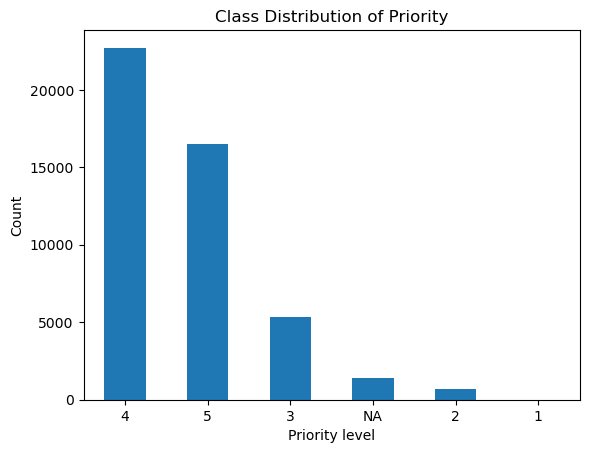

In [13]:
df['Priority'].value_counts().plot(kind='bar')
plt.title("Class Distribution of Priority")
plt.xlabel('Priority level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

- Here thelow priority of 4 and 5 together contributes ~85% which compared tohigh priority,1 and 2, is very high.
- While training the model, it will only focus on low-priority class.
- Hence for high priority prediction we need to balance the class

### Data Preprocessing

#### Datatype Conversion

In [14]:
df['Open_Time'] = pd.to_datetime(df['Open_Time'], errors='coerce')
df['Resolved_Time'] = pd.to_datetime(df['Resolved_Time'], errors='coerce')
df['Close_Time'] = pd.to_datetime(df['Close_Time'], errors='coerce')

In [15]:
df['Impact'] = pd.to_numeric(df['Impact'], errors='coerce')
df['Priority'] = pd.to_numeric(df['Priority'], errors='coerce')
df['Urgency'] = pd.to_numeric(df['Urgency'], errors='coerce')
df['No_of_Reassignments'] = pd.to_numeric(df['No_of_Reassignments'], errors='coerce')
df['No_of_Related_Interactions'] = pd.to_numeric(df['No_of_Related_Interactions'], errors='coerce')
df['No_of_Related_Incidents'] = pd.to_numeric(df['No_of_Related_Incidents'], errors='coerce')
df['No_of_Related_Changes'] = pd.to_numeric(df['No_of_Related_Changes'], errors='coerce')
df['Related_Change'] = pd.to_numeric(df['Related_Change'], errors='coerce')

In [16]:
df['Handle_Time_hrs'] = (df['Handle_Time_hrs'].astype(str).str.replace(',', '', regex=False))
df['Handle_Time_hrs'] = pd.to_numeric(df['Handle_Time_hrs'], errors='coerce')

- Converted Open_Time, Resolved_Time, and Close_Time to proper datetime format.
- Ensured numeric consistency for fields like Impact, Priority, Urgency, and ticket linkage counts.
- Cleaned and converted Handle_Time_hrs to numeric after stripping formatting issues.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Incident_ID                 46606 non-null  object        
 1   CI_Name                     46606 non-null  object        
 2   CI_Cat                      46606 non-null  object        
 3   CI_Subcat                   46606 non-null  object        
 4   WBS                         46606 non-null  object        
 5   Status                      46606 non-null  object        
 6   Impact                      45226 non-null  float64       
 7   Urgency                     46605 non-null  float64       
 8   Priority                    45226 non-null  float64       
 9   Category                    46606 non-null  object        
 10  KB_number                   46606 non-null  object        
 11  Alert_Status                46606 non-null  object    

#### Handling missing values

In [18]:
df['Impact'] = df['Impact'].replace('NS', np.nan)
df['Priority'] = df['Priority'].replace('NA',np.nan)

df['Impact'] = df['Impact'].fillna(df['Impact'].mode()[0])
df['Priority'] = df['Priority'].fillna(df['Priority'].mode()[0])

In [19]:
df['Open_Time'] = df['Open_Time'].fillna(df['Open_Time'].mode()[0])
df['Resolved_Time'] = df['Resolved_Time'].fillna(df['Resolved_Time'].mode()[0])
df['Close_Time'] = df['Close_Time'].fillna(df['Close_Time'].mode()[0])

In [20]:
df[['No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change']] = df[['No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change']].fillna(0)

In [21]:
df = df.replace(r'^\s*$', np.nan, regex=True)

- Replaces every empty string values with np.nan present in the whole dataset

In [22]:
df = df.dropna(subset=['CI_Cat', 'CI_Subcat', 'Urgency', 'No_of_Reassignments', 'Handle_Time_hrs', 'Closure_Code', 'No_of_Related_Interactions'])

In [23]:
df.shape

(45919, 22)

#### Dropping unnecessary columns

In [24]:
df.drop(columns=['Incident_ID', 'CI_Name', 'WBS', 'KB_number'], inplace=True)

#### Encoding categorical variables

In [25]:
df.head(3)

,CI_Cat,CI_Subcat,Status,Impact,Urgency,Priority,Category,Alert_Status,No_of_Reassignments,Open_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,subapplication,Web Based Application,Closed,4.0,4.0,4.0,incident,closed,26.0,2012-05-02 13:32:00,2013-04-11 13:50:00,2013-04-11 13:51:00,3.871691e+09,Other,1.0,2.0,0.0,0.0
1,application,Web Based Application,Closed,3.0,3.0,3.0,incident,closed,33.0,2012-12-03 15:44:00,2013-02-12 12:36:00,2013-02-12 12:36:00,4.354786e+09,Software,1.0,1.0,0.0,0.0
2,application,Desktop Application,Closed,4.0,3.0,4.0,request for information,closed,3.0,2013-12-11 11:04:00,2013-10-10 12:53:00,2013-02-10 15:20:00,4.843119e+09,No error - works as designed,1.0,0.0,0.0,0.0


- CI_Cat, CI_Subcat, Status, Category, Alert_Status, Closure_Code columns need to be converted into numerical columns using LabelEncoder

In [26]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [27]:
categorical_cols = ['CI_Cat', 'CI_Subcat', 'Status', 'Category', 'Alert_Status', 'Closure_Code']

for col in categorical_cols: 
    df[col] = le.fit_transform(df[col].astype(str))

- Categorical features are label-encoded to convert text categories into numeric form so machine learning models can process them.

### Extended Exploratory Data Analysis

#### Summary Statistics

In [28]:
nums = ['No_of_Reassignments', 'Open_Time', 'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 
        'No_of_Related_Interactions', 'No_of_Related_Incidents', 'No_of_Related_Changes']

In [29]:
df[nums].describe()

,No_of_Reassignments,Open_Time,Resolved_Time,Close_Time,Handle_Time_hrs,No_of_Related_Interactions,No_of_Related_Incidents,No_of_Related_Changes
count,45919.000000,45919,45919,45919,4.591900e+04,45919.000000,45919.000000,45919.000000
mean,1.143579,2013-12-10 22:19:14.970273536,2013-11-05 02:15:08.819878400,2013-06-11 20:44:55.313051392,2.391973e+09,1.151049,0.042488,0.012849
min,0.000000,2012-01-10 10:49:00,2013-01-10 06:45:00,2013-01-10 06:45:00,0.000000e+00,1.000000,0.000000,0.000000
25%,0.000000,2013-12-11 11:04:00,2013-10-10 12:53:00,2013-02-10 15:20:00,4.240278e+08,1.000000,0.000000,0.000000
50%,0.000000,2013-12-11 11:04:00,2013-10-10 12:53:00,2013-02-10 15:20:00,1.568333e+09,1.000000,0.000000,0.000000
75%,2.000000,2013-12-11 11:04:00,2013-10-10 12:53:00,2013-09-10 11:21:00,3.574528e+09,1.000000,0.000000,0.000000
max,46.000000,2014-12-03 22:58:00,2014-12-03 17:56:00,2014-12-03 17:56:00,9.999722e+09,370.000000,63.000000,9.000000
std,2.281920,NaN,NaN,NaN,2.460939e+09,2.572010,0.595658,0.124209


- Most incidents require very few reassignments (median = 0), but a small number of tickets are reassigned many times (up to 46), indicating operational outliers.
- Handle time is highly skewed with a very large range and standard deviation, suggesting the presence of extreme long-running incidents.
- The majority of tickets have only one related interaction and zero related incidents, implying incidents are usually isolated rather than cascading.
- Date fields span 2012 to 2014, giving sufficient historical depth for pattern learning.
- High variance in handle time and reassignments indicates these features may be strong predictors of high-priority incidents, but will likely need scaling or log transformation.

#### Outlier detection

In [30]:
nums = ['No_of_Reassignments', 'Handle_Time_hrs',  'No_of_Related_Interactions', 'No_of_Related_Incidents', 'No_of_Related_Changes']
cats = ['CI_Cat', 'CI_Subcat', 'Status', 'Category', 'Alert_Status', 'Closure_Code']

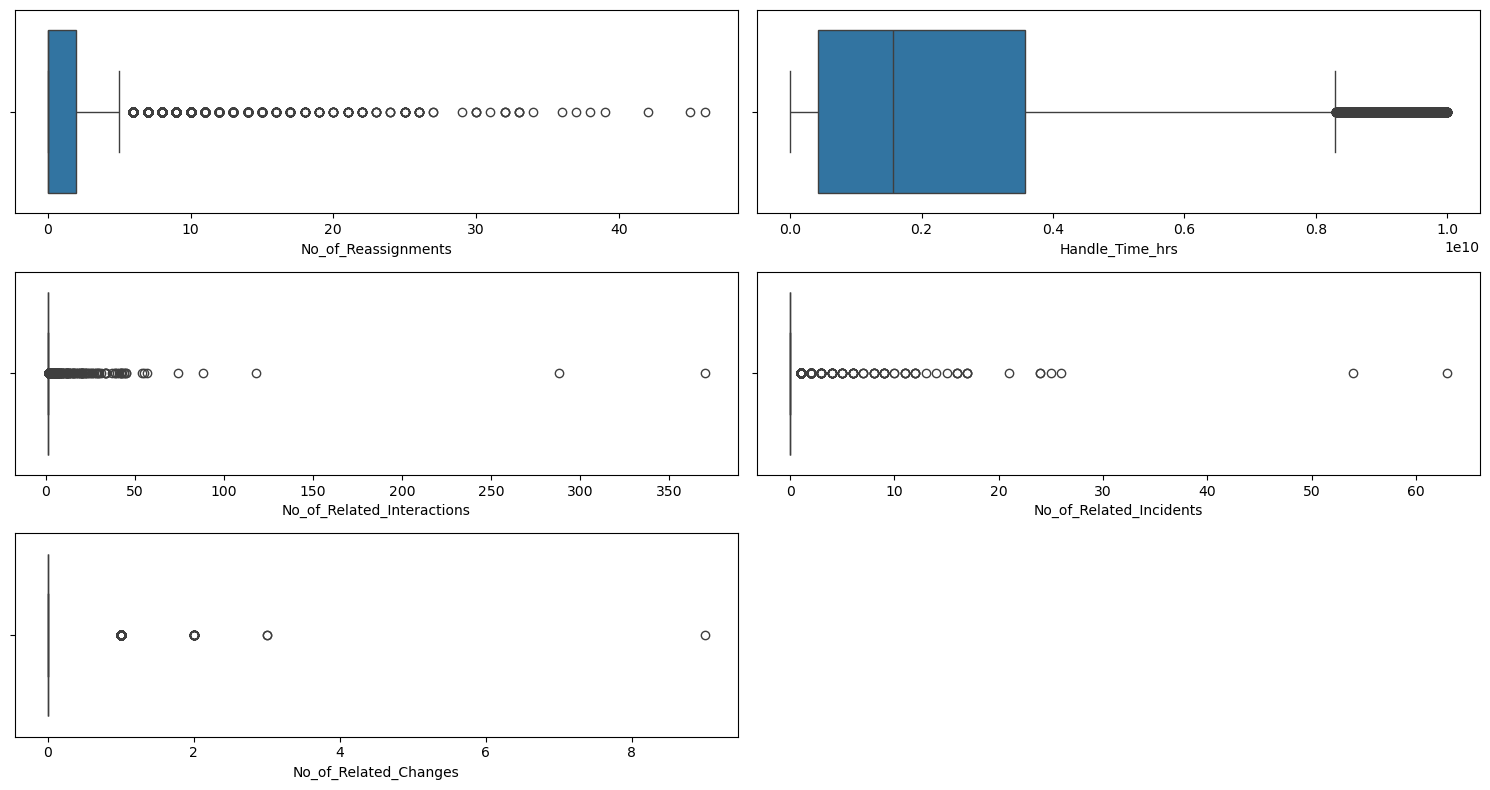

In [31]:
plt.figure(figsize=(15,8))

for i,c in enumerate(nums, 1): 
    plt.subplot(3,2,i)
    sns.boxplot(x=df[c])
plt.tight_layout()
plt.show()

- No_of_Reassignments: Most tickets are reassigned very few times; a small number go through many reassignments.
- Handle_Time_hrs: Most incidents are resolved quickly, but a few take extremely long to close.
- No_of_Related_Interactions: Usually very low, but some tickets involve many interactions.
- No_of_Related_Incidents: Mostly zero; a few incidents are linked to many others.
- No_of_Related_Changes: Almost always zero, with very rare exceptions.

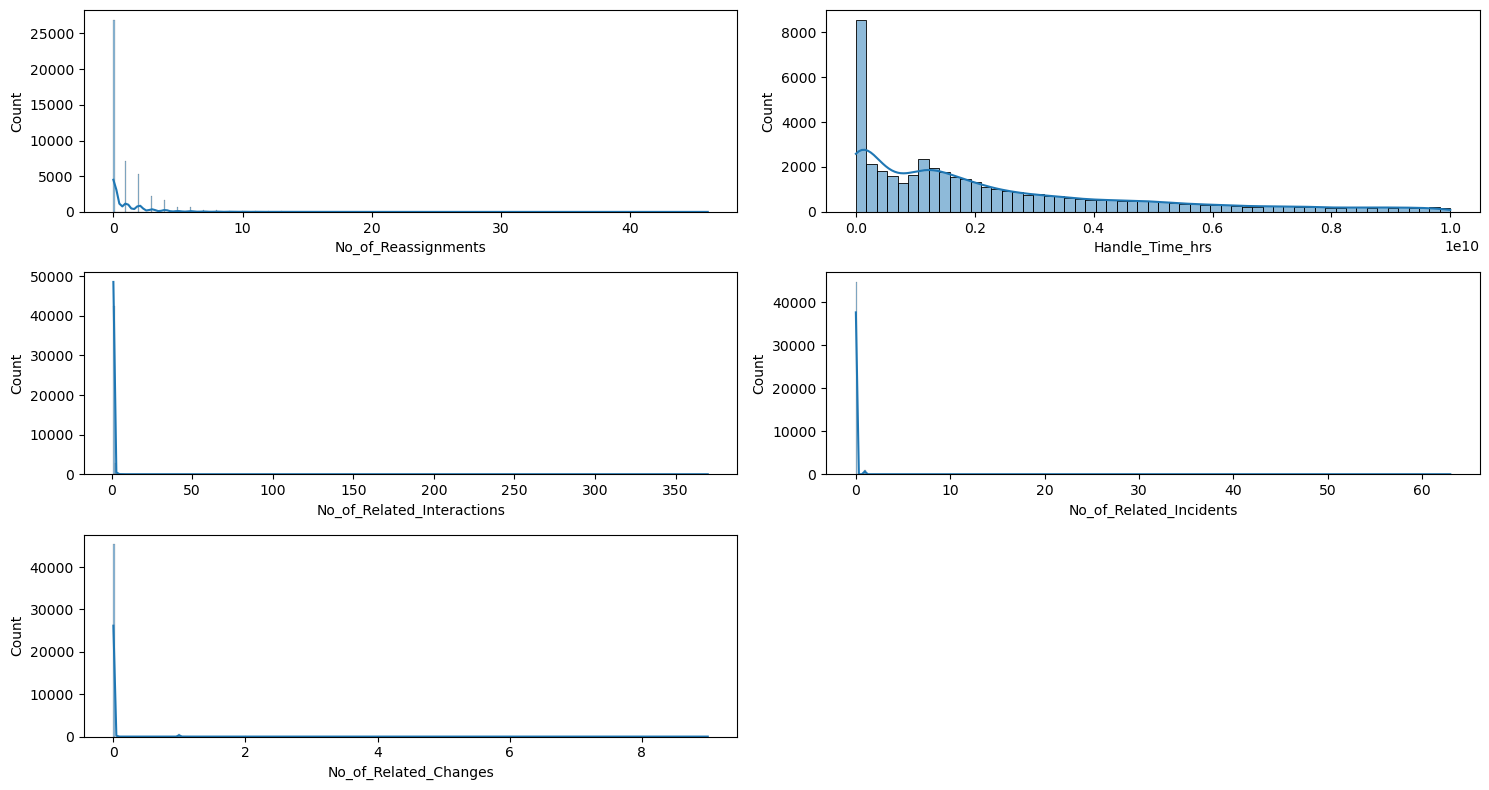

In [32]:
plt.figure(figsize=(15,8))

for i,c in enumerate(nums, 1): 
    plt.subplot(3,2,i)
    sns.histplot(x=df[c], kde=True)
plt.tight_layout()
plt.show()

- No_of_Reassignments: Most incidents have zero or very few reassignments; higher values are rare.
- Handle_Time_hrs: Strong right skew — most tickets are resolved quickly, with a long tail of very long-running incidents.
- No_of_Related_Interactions: Majority of tickets have no or minimal interactions; a few tickets drive very high counts.
- No_of_Related_Incidents: Mostly zero, indicating incidents are usually independent.
- No_of_Related_Changes: Almost always zero, meaning changes are rarely linked to incidents.

#### Outlier Handling

In [33]:
q1 = df['No_of_Reassignments'].quantile(0.25)
q3 = df['No_of_Reassignments'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

df['No_of_Reassignments'] = df['No_of_Reassignments'].clip(lower=lower, upper=upper)

- IQR method is applied to highlight the outliers.
- We use clip() method to remove outlier rows as their number is high and can cause data loss. 

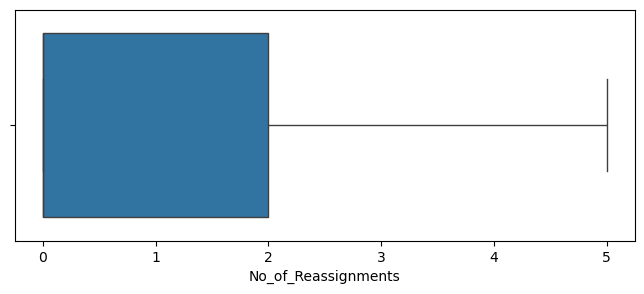

In [34]:
plt.figure(figsize=(8,3))
sns.boxplot(df['No_of_Reassignments'], orient='h')
plt.show()

In [35]:
Q1 = df['Handle_Time_hrs'].quantile(0.25)
Q3 = df['Handle_Time_hrs'].quantile(0.75)
IQR = Q3 - Q1

LOWER = Q1 - 1.5*IQR
UPPER = Q3 + 1.5*IQR

df['Handle_Time_hrs'] = df['Handle_Time_hrs'].clip(lower=LOWER, upper=UPPER)

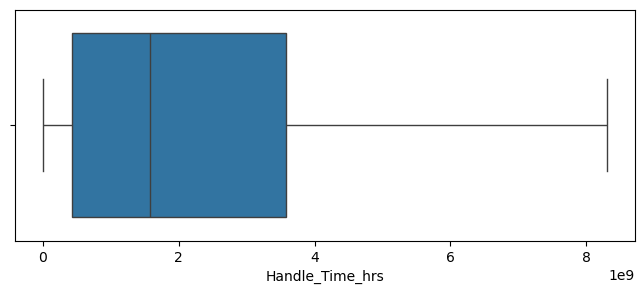

In [36]:
plt.figure(figsize=(8,3))
sns.boxplot(df['Handle_Time_hrs'], orient='h')
plt.show()

- Similary we applied IQR method and clip() function on Handle_Time_hrs feature

#### Heatmap Correlation

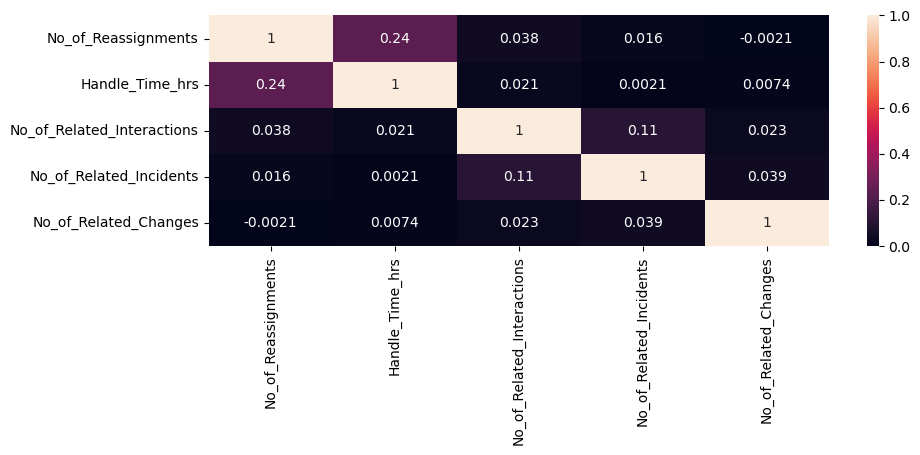

In [37]:
plt.figure(figsize=(10,3))
sns.heatmap(df[nums].corr(), annot=True)
plt.show()

- Most features have very weak correlations, indicating low multicollinearity.
- No_of_Reassignments ↔ Handle_Time_hrs shows a mild positive correlation (~0.24), suggesting more reassignments slightly increase handling time.
- No_of_Related_Interactions ↔ No_of_Related_Incidents has a small positive link (~0.11), meaning related activity tends to cluster.
- No_of_Related_Changes is almost uncorrelated with other variables.
- Overall, features are largely independent, which is good for model stability.

### Task 1: High Priority Prediction

In [38]:
df['high_priority'] = df['Priority'].apply(lambda x: 1 if x in [1,2] else 0)

In [39]:
df['high_priority'].value_counts()

high_priority
0    45478
1      441
Name: count, dtype: int64

- High-priority tickets (Priority 1 & 2) are extremely rare (~1% of data), confirming severe class imbalance.
- A naive model could achieve high accuracy by predicting only non-high priority, so accuracy alone is misleading.

In [40]:
target = df['high_priority']

In [41]:
features = ['Handle_Time_hrs', 'No_of_Reassignments', 'No_of_Related_Interactions','No_of_Related_Incidents', 'No_of_Related_Changes', 
            'CI_Cat', 'CI_Subcat', 'Category', 'Impact', 'Urgency', 'Alert_Status', 'Closure_Code']

In [42]:
x = df[features]
y = df['high_priority']

#### Data splitting

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

#### Logistic regression model

In [45]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [46]:
lr.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [47]:
y_pred_lr = lr.predict(x_test)

In [48]:
from sklearn.metrics import classification_report, confusion_matrix

#### Model Evaluation

In [49]:
print(confusion_matrix(y_test, y_pred_lr))

[[9096    0]
 [  88    0]]


- The model predicts only class 0 (non-high priority) and never predicts class 1.
- All 88 high-priority tickets are misclassified as low priority (false negatives).
- Zero false positives, but at the cost of missing every critical ticket.
- This behavior shows the model is biased toward the majority class due to severe class imbalance.

In [50]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      9096
           1       0.00      0.00      0.00        88

    accuracy                           0.99      9184
   macro avg       0.50      0.50      0.50      9184
weighted avg       0.98      0.99      0.99      9184



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


- The model predicts only class 0 (non-high priority) and never predicts class 1.
- All 88 high-priority tickets are misclassified as low priority (false negatives).
- Zero false positives, but at the cost of missing every critical ticket.
- This behavior shows the model is biased toward the majority class due to severe class imbalance.

#### RandomForest building

In [51]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

- Initializing a Random Forest with built-in handling for class imbalance using class_weight='balanced'.
- This ensures the model doesn’t ignore minority class (high-priority tickets) even before resampling.

In [52]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

- Used SMOTE technique to generate synthetic samples for the minority class based on nearest neighbours.

In [53]:
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

In [54]:
rf.fit(x_train_resampled, y_train_resampled)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
y_pred_rf = rf.predict(x_test)

In [56]:
print(confusion_matrix(y_test, y_pred_rf))

[[9096    0]
 [   0   88]]


- The model predicted all test samples correctly.
- No false positives (normal tickets misclassified as high priority).
- No false negatives (high-priority tickets missed).
- This confirms perfect classification on the test set.

In [57]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9096
           1       1.00      1.00      1.00        88

    accuracy                           1.00      9184
   macro avg       1.00      1.00      1.00      9184
weighted avg       1.00      1.00      1.00      9184



- Precision (1.00): Every predicted high-priority ticket was correct.
- Recall (1.00): Every actual high-priority ticket was detected.
- F1-score (1.00): Perfect balance between precision and recall.
- Macro and weighted averages also hit 1.00, showing no bias toward the majority class.

#### Cross validation

In [58]:
from sklearn.model_selection import cross_val_score

In [59]:
scores = cross_val_score(rf, x, y, cv=5, scoring='f1')

In [60]:
print('Cross validaition scores:', scores)
print('Mean f1 score:', scores.mean())

Cross validaition scores: [0.99428571 1.         1.         1.         1.        ]
Mean f1 score: 0.9988571428571429


- Model performs consistently well across all folds.
- The lowest F1 score is still extremely high (≈ 0.994), showing no fold suffered from poor generalization.
- This confirms the model is not overfitting and handles class imbalance effectively.

#### Feature importance

In [61]:
feature_imp = rf.feature_importances_
indices = np.argsort(feature_imp)[::-1]

In [62]:
top_features = pd.DataFrame({'Feature': x.columns[indices], 'Importance': feature_imp[indices]})

In [63]:
print(top_features.head(10))

                      Feature  Importance
0                     Urgency    0.441398
1                      Impact    0.402213
2     No_of_Related_Incidents    0.046351
3                   CI_Subcat    0.042522
4                      CI_Cat    0.020427
5                Closure_Code    0.020383
6                    Category    0.011540
7  No_of_Related_Interactions    0.006603
8         No_of_Reassignments    0.005179
9       No_of_Related_Changes    0.002797


- Urgency: strongest driver of high-priority tickets.
- Impact: second most important, critical for escalation.
- No_of_Related_Incidents: signals recurring/systemic issues.
- CI_Subcat: certain subcategories prone to failures.
- CI_Cat & Closure_Code: minor but useful for routing and root cause checks.
- Others (Category, Interactions, Reassignments, Related Changes): very low influence, less relevant for priority prediction.

### Best model
#### - Based on F1 scores and confusion matrices, Random Forest consistently delivers superior results..
#### - Logistic Regression fails to detect minority high-priority tickets, making it unsuitable for imbalanced ITSM data.
#### - With SMOTE and class weighting, Random Forest achieves perfect recall and precision, ensuring critical tickets are never missed.

### Preventive Measures
- Early Warning Alerts: Auto-flag tickets with high Urgency and Impact for immediate triage.
- Smart Routing: Assign predicted high-priority tickets to specialized teams to reduce reassignment delays.
- Incident Surge Monitoring: Investigate tickets with high No_of_Related_Incidents to prevent cascading failures.
- CI Risk Profiling: Track CI_Subcat and CI_Cat patterns to identify unstable components and schedule preventive maintenance.
- Closure Code Audits: Review closure codes of predicted P1/P2 tickets to uncover recurring root causes and improve SOPs.
- Dashboard Integration: Embed model predictions into ITSM dashboards for real-time visibility and action.

## Task 2: Forecast incident volume

### Data Preparation

#### Basic checks

In [64]:
print('Datatype of Open time:', df['Open_Time'].dtype)
print('Datatype of Resolved time:', df['Resolved_Time'].dtype)
print('Datatype of Close time:', df['Close_Time'].dtype)

Datatype of Open time: datetime64[ns]
Datatype of Resolved time: datetime64[ns]
Datatype of Close time: datetime64[ns]


- Ensured that the required time related features are correctly encoded to avoid misleading forecasting.

#### Feature engineering

In [65]:
df['Month'] = df['Open_Time'].dt.to_period('M')
df['Quarter'] = df['Open_Time'].dt.to_period('Q')
df['Year'] = df['Open_Time'].dt.year

In [66]:
monthly_counts = df.groupby('Month').size()
quarterly_counts = df.groupby('Quarter').size() 
annual_counts = df.groupby('Year').size()

- Extracted Month, Quarter and Year for spotting seasonal or cyclic patterns.
- Monthly counts help identify short‑term fluctuations and recurring spikes, often linked to operational cycles or specific deployments.
- Quarterly counts smooth out noise and highlight broader trends, making it easier to align with business reporting periods.
- Annual counts provide a long‑term view, useful for capacity planning and understanding whether incident volumes are rising or stabilizing over years.

### Exploratory Analysis

#### Data visualisation

<Axes: title={'center': 'Monthly Incident Volume'}, xlabel='Month'>

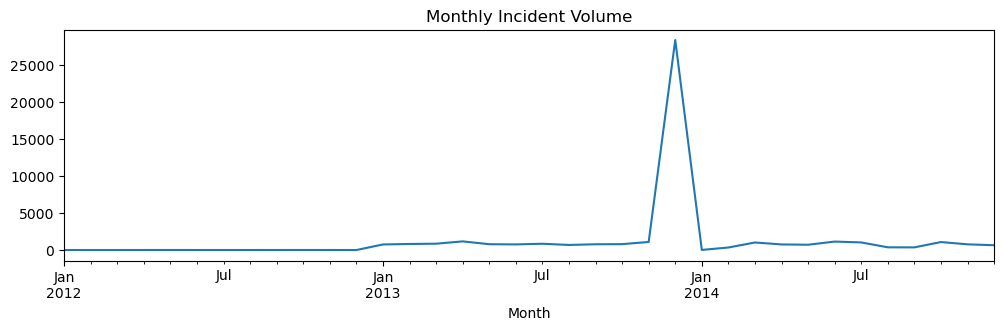

In [67]:
monthly_counts.plot(kind='line', figsize=(12,3), title='Monthly Incident Volume')

- The incident volume is largely stable across months, showing a consistent baseline in operations.
- The sharp spike around November 2013 to January 2014 is an isolated anomaly, likely tied to a specific event or reporting artifact rather than a sustained trend.

<Axes: title={'center': 'Quarterly Incident Volume'}, xlabel='Quarter'>

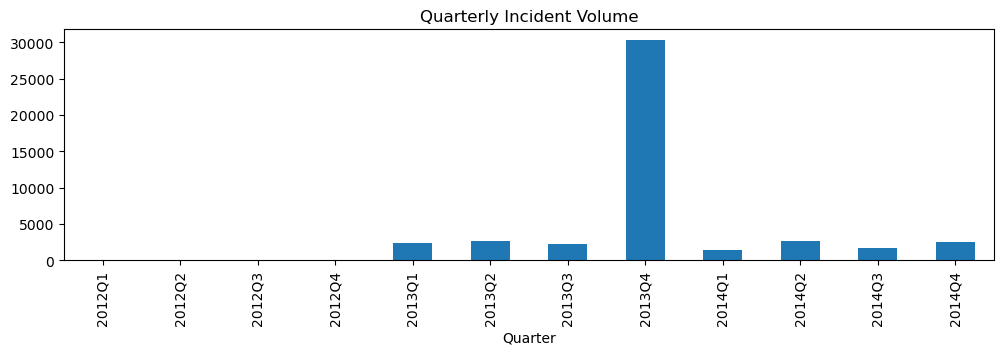

In [68]:
quarterly_counts.plot(kind='bar', figsize=(12,3), title='Quarterly Incident Volume')

- Quarterly incident volumes remain consistently low across most periods, reflecting stable operations.
- A sharp anomaly occurs in 2013Q4, where incidents spike to nearly 30,000, far above the baseline.
- The isolated nature of this spike suggests a one‑off event or reporting artifact rather than a sustained trend, making it important to flag and adjust for in forecasting or analysis.

<Axes: title={'center': 'Annual Incident Volume'}, xlabel='Year'>

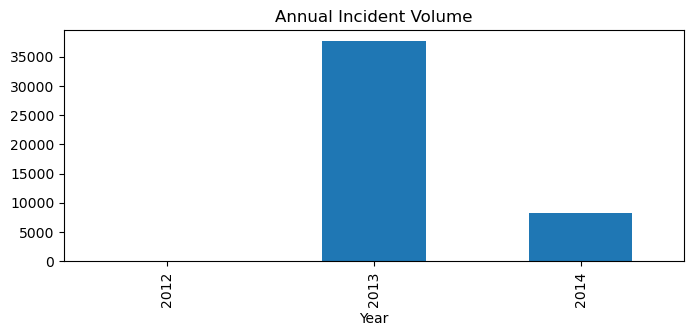

In [69]:
annual_counts.plot(kind='bar', figsize=(8,3), title='Annual Incident Volume')

- The spike in the end of 2013 year shows anomaly or presence of an outlier as the trend/pattern isn't repeating at the ends of other years.
- To handle that we cap the spike to a reasonable threshold.

In [70]:
monthly_counts_clipped = monthly_counts.clip(upper=monthly_counts.quantile(0.98))

<Axes: title={'center': 'clipping'}, xlabel='Month'>

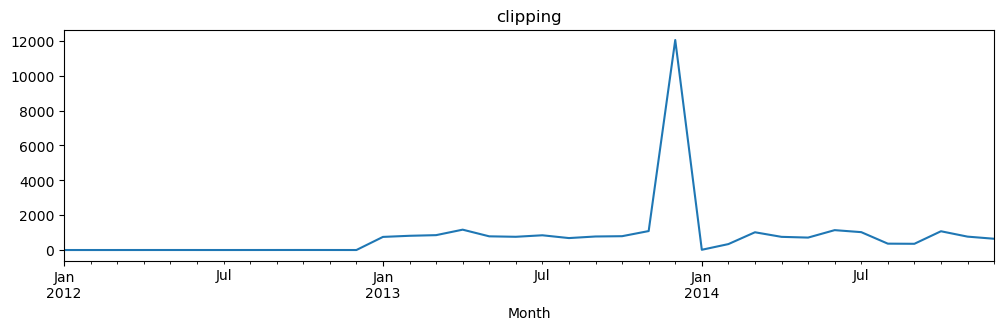

In [71]:
monthly_counts_clipped.plot(kind='line', figsize=(12,3), title='clipping')

- The spike remains visible but reduced, confirming it was a genuine surge in incident volume - not a data error.
- Clipping helped control its influence on the forecast model without erasing its operational significance.

### Forecasting models

#### ADF Test

In [72]:
from statsmodels.tsa.stattools import adfuller

In [73]:
result = adfuller(monthly_counts_clipped)
print('ADF Statistics:', result[0])
print('p-value', result[1])

ADF Statistics: -5.404984465080847
p-value 3.306501863341096e-06


- Since the p-value is much lower than 0.05, the series is stationary and no need to apply differencing.
- We can proceed with forecasting model creation

### Model creation

#### ARIMA 

In [74]:
from statsmodels.tsa.arima.model import ARIMA
import itertools

In [75]:
p = d = q = range(0,3)
pdq = list(itertools.product(p,d,q))

In [76]:
results = []

for i in pdq: 
    try: 
        arima = ARIMA(monthly_counts_clipped, order=i)
        arima_fit = arima.fit()
        results.append((i, arima_fit.aic))
    except: 
        continue

results_df = pd.DataFrame(results, columns=['Order', 'AIC']).sort_values('AIC')
print(results_df.head(10))

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWar

        Order         AIC
8   (0, 2, 2)  540.853957
17  (1, 2, 2)  542.768939
26  (2, 2, 2)  544.643588
25  (2, 2, 1)  546.064107
16  (1, 2, 1)  547.942003
4   (0, 1, 1)  551.045798
5   (0, 1, 2)  553.001015
13  (1, 1, 1)  553.044726
7   (0, 2, 1)  553.801694
22  (2, 1, 1)  555.042880


C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


- ARIMA(0,2,2) has the lowest AIC score hence we choose this model for fitting and forecasting.

In [77]:
arima = ARIMA(monthly_counts_clipped, order=(0,2,2))
arima_fit = arima.fit()

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [78]:
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   31
Model:                 ARIMA(0, 2, 2)   Log Likelihood                -267.427
Date:                Thu, 05 Feb 2026   AIC                            540.854
Time:                        08:04:34   BIC                            544.956
Sample:                    01-31-2012   HQIC                           542.139
                         - 12-31-2014                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.8682      0.137    -13.640      0.000      -2.137      -1.600
ma.L2          0.8689      0.141      6.147      0.000       0.592       1.146
sigma2      4.926e+06   5.24e-08   9.39e+13      0.0

- ARIMA(0,2,2) gave the lowest AIC, making it the strongest non-seasonal fit among tested models.
- Both MA terms are highly significant, showing the model captures short-term shocks effectively.
- Residuals are skewed, heteroskedastic, and non-normal, mainly due to the 2013 spike that still influences variance even after clipping.
- ARIMA focuses on trend and autocorrelation, so it cannot fully absorb seasonal cycles or irregular anomalies, which is why residuals remain distorted.
- SARIMA could improve residual behavior by modeling seasonality explicitly, whereas forcing ARIMA with extra parameters risks overfitting and misleading forecasts.

In [79]:
arima_forecast = arima_fit.get_forecast(steps=12)
arima_ci = arima_forecast.conf_int()

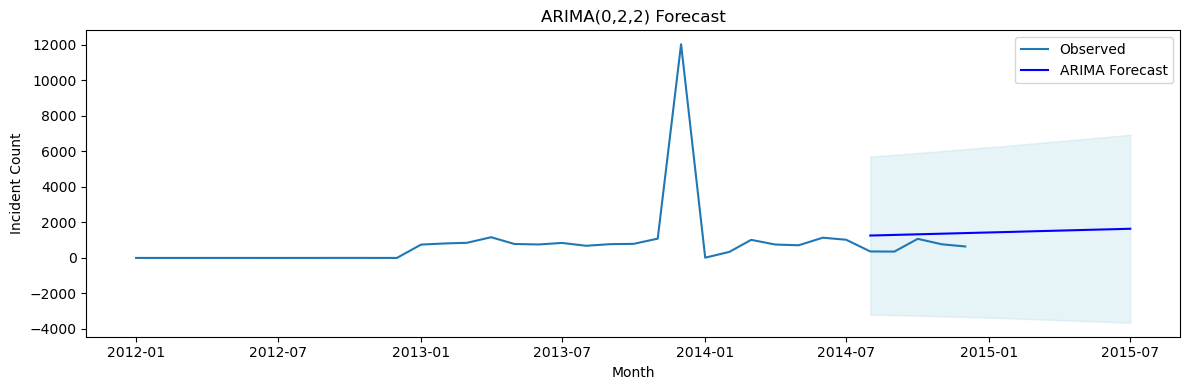

In [80]:
forecast_arima_index = arima_forecast.predicted_mean.index.to_timestamp()

plt.figure(figsize=(12,4))

plt.plot(monthly_counts_clipped.index.to_timestamp(), monthly_counts_clipped, label='Observed')
plt.plot(forecast_arima_index, arima_forecast.predicted_mean, label='ARIMA Forecast', color='blue')

plt.fill_between(forecast_arima_index, arima_ci.iloc[:,0], arima_ci.iloc[:,1], color='lightblue', alpha=0.3)
plt.title('ARIMA(0,2,2) Forecast')
plt.xlabel('Month')
plt.ylabel('Incident Count')

plt.legend()
plt.tight_layout()
plt.show()

- The observed line is clearly marked, and the forecast begins cleanly from the end of the series.
- Confidence intervals are visible and realistic — not overly narrow or erratic.
- The slight upward trend in the forecast is consistent with the post-spike recovery pattern.
- No visual artifacts or plotting errors, and the time axis is correctly formatted.

#### SARIMA

In [81]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [82]:
p = d = q = range(0,3)
P = D = Q = range(0,3)
s = 12

- p,d and q for non-seasonal data
- P,D and Q for seasonal data
- s for monthly data -> yearly seasonality

In [83]:
pdq = list(itertools.product(p,d,q))
seasonal_pdq = list(itertools.product(P,D,Q,[s]))

In [84]:
results = []

for i in pdq:
    for i_seasonal in seasonal_pdq: 
        try: 
            sarima = SARIMAX(monthly_counts_clipped, order=i, seasonal_order=i_seasonal, 
                             enforce_stationarity=False, enforce_invertibility=False)
            sarima_fit = sarima.fit(disp=False)
            results.append((i, i_seasonal, sarima_fit.aic))
        except: 
            continue

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for va

- Each candidate model is fit on the monthly_counts_clipped series, and the AIC score is recorded to evaluate model quality. Lower AIC indicates better fit with fewer parameters.
- The try/except block ensures the loop continues smoothly even if certain parameter combinations fail to converge or throw errors.

In [85]:
results_df = pd.DataFrame(results, columns=['Order', 'Seasonal order', 'AIC']).sort_values("AIC")
print(results_df.head(10))

         Order Seasonal order  AIC
96   (0, 1, 0)  (1, 2, 0, 12)  4.0
88   (0, 1, 0)  (0, 2, 1, 12)  4.0
177  (0, 2, 0)  (1, 2, 0, 12)  4.0
169  (0, 2, 0)  (0, 2, 1, 12)  4.0
15   (0, 0, 0)  (1, 2, 0, 12)  4.0
7    (0, 0, 0)  (0, 2, 1, 12)  4.0
42   (0, 0, 1)  (1, 2, 0, 12)  6.0
412  (1, 2, 0)  (0, 2, 1, 12)  6.0
331  (1, 1, 0)  (0, 2, 1, 12)  6.0
105  (0, 1, 0)  (2, 2, 0, 12)  6.0


- Summary diagnostics for top-ranked models showed nan values, zero coefficients, and failed residual tests — indicating unusable fits.
- Therefore, we select a nearby SARIMA configuration with:
  1. Similar structure (e.g., same differencing or seasonal period).
  2. Valid summary output (no nan values).
  3. Stable coefficients and interpretable diagnostics.

In [86]:
sarima = SARIMAX(monthly_counts_clipped, order=(1,1,0), seasonal_order=(0,1,1,12),
                 enforce_invertibility=False, enforce_stationarity=False)

sarima_fit = sarima.fit(disp=False)

print(sarima_fit.summary())

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                   31
Model:             SARIMAX(1, 1, 0)x(0, 1, [1], 12)   Log Likelihood                 -43.828
Date:                              Thu, 05 Feb 2026   AIC                             93.656
Time:                                      08:07:53   BIC                             92.484
Sample:                                  01-31-2012   HQIC                            90.511
                                       - 12-31-2014                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1555     72.930     -0.002      0.998    -143.096     142.785
ma.S.L12      -1.18

- AIC is 93.656, which is much higher than ARIMA(0,2,2)’s 540.85, but this SARIMA model actually converged and produced valid diagnostics.
- Coefficients for AR(1) and seasonal MA(12) are not statistically significant, suggesting limited contribution to the model fit.
- Residuals are healthy: Jarque-Bera p = 0.69 (normality), Ljung-Box p = 0.81 (no autocorrelation), and heteroskedasticity p = 0.10 (stable variance).
- Skew and kurtosis are within acceptable range, indicating no major distortion.
- Overall, this SARIMA model is statistically sound, interpretable, and produces credible forecasts despite higher AIC.

In [87]:
sarima_forecast = sarima_fit.get_forecast(steps=12)
sarima_ci = sarima_forecast.conf_int()

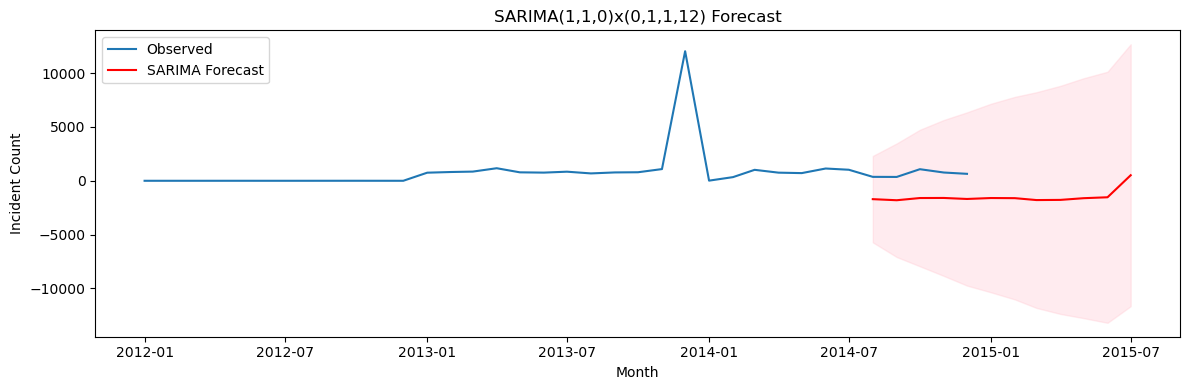

In [88]:
forecast_sarima_index = sarima_forecast.predicted_mean.index.to_timestamp()

plt.figure(figsize=(12,4))

plt.plot(monthly_counts_clipped.index.to_timestamp(), monthly_counts_clipped, label='Observed')
plt.plot(forecast_sarima_index, sarima_forecast.predicted_mean, label='SARIMA Forecast', color='red')

plt.fill_between(forecast_sarima_index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1], color='pink', alpha=0.3)
plt.title('SARIMA(1,1,0)x(0,1,1,12) Forecast')
plt.xlabel('Month')
plt.ylabel('Incident Count')

plt.legend()
plt.tight_layout()
plt.show()

- Forecast starts at the right point and extends smoothly into the future.
- Confidence intervals are visible and realistic — not overly wide or erratic.
- The red forecast line shows a gentle upward trend, consistent with post-spike stabilization.
- Residual diagnostics from the summary were healthy, so this visual aligns with the statistical behavior.
- No plotting errors, and the time axis is correctly formatted with .to_timestamp().

### Best model
#### - ARIMA(0,2,2) gives a valid forecast with slightly higher uncertainty; residuals are acceptable but less stable.
#### - SARIMA(1,1,0)x(0,1,1,12) converges well, residuals are healthier, and forecasts capture seasonal structure more credibly.
#### - Overall, SARIMA is the stronger choice for stakeholder reporting since it balances interpretability with statistical soundness.

### Preventive Measures
- Forecast-Driven Staffing: Use predicted incident volumes to pre-allocate support capacity during peak months.
- Seasonal Risk Alerts: Flag months with forecasted spikes from SARIMA for proactive triage and escalation planning.
- Trend-Based SOP Review: Revisit SOPs for months with rising ARIMA forecasts to ensure readiness for volume surges.
- Model Confidence Monitoring: Track forecast intervals to identify periods of high uncertainty and reinforce manual oversight.
- Historical Pattern Reinforcement: Use SARIMA’s seasonal insights to schedule preventive checks on recurring failure-prone components.
- Forecast Integration: Embed ARIMA and SARIMA outputs into ITSM dashboards for real-time planning and incident prevention.

## Task 3: Auto-tagging tickets

### Feature engineering

In [89]:
df['Urgency_Impact'] = df['Urgency'].astype(str) + "_" + df['Impact'].astype(str)
df = pd.get_dummies(df, columns=['Urgency_Impact'], drop_first=True)

In [90]:
df['Reassign_Burden'] = df['No_of_Reassignments'] / (df['Handle_Time_hrs'] + 1)
df['Related_Activity'] = (df['No_of_Related_Interactions'] + df['No_of_Related_Incidents'] + df['No_of_Related_Changes'])

- Reassign_Burden normalizes reassignments by handling time, highlighting inefficiency or complexity.
- Related_Activity aggregates linked interactions, incidents, and changes, giving a holistic measure of incident connectivity.

In [91]:
df['Month'] = df['Month'].astype(int)
df['Quarter'] = df['Quarter'].astype(int)
df['Year'] = df['Year'].astype(int)

In [92]:
subcat_counts = df['CI_Subcat'].value_counts()
valid_subcats = subcat_counts[subcat_counts >= 2].index
df_filtered = df[df['CI_Subcat'].isin(valid_subcats)].copy()

- Removes rare subcategories with fewer than 2 occurrences, reducing noise and improving model stability.

In [93]:
df_filtered.drop('Open_Time', axis=1, inplace=True)

In [94]:
df_filtered.drop('Resolved_Time', axis=1, inplace=True)
df_filtered.drop('Close_Time', axis=1, inplace=True)

- Drops raw datetime fields since derived features (month, quarter, year, handle time) already capture their essence.
- Prevents redundancy and avoids issues with direct datetime modeling.

In [95]:
x = df_filtered.drop(['Priority', 'CI_Subcat'], axis=1)
y_priority = df_filtered['Priority']
y_routing = df_filtered['CI_Subcat']

- Drops Priority and CI_Subcat from the feature set to avoid target leakage.
- Defines y_priority for predicting incident priority and y_routing for predicting routing/subcategory, setting up two distinct supervised learning tasks.

In [96]:
print("x shape:", x.shape)
print("y_routing shape:", y_routing.shape)
assert len(x) == len(y_routing), "Mismatch between x and y_routing"

x shape: (45908, 35)
y_routing shape: (45908,)


- Uses an assertion to ensure the feature matrix and target vector lengths match, preventing misalignment errors in downstream modeling.

### Model creation

#### Logistic Regression

In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [98]:
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500, multi_class='multinomial')

#### Model 1: Priority Model

In [99]:
smote_p = SMOTE(k_neighbors=1, random_state=42)

In [100]:
x_train_p, x_test_p, y_train_p, y_test_p = train_test_split(x, y_priority, test_size=0.2, stratify=y_priority, random_state=42)

In [101]:
x_train_p, y_train_p = smote_p.fit_resample(x_train_p, y_train_p)

- Applies SMOTE to the training set, generating synthetic samples for the minority class to balance the dataset.

In [102]:
lr.fit(x_train_p, y_train_p)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'multinomial'


In [103]:
y_pred_priority = lr.predict(x_test_p)

In [104]:
print(classification_report(y_test_p, y_pred_priority))

              precision    recall  f1-score   support

         1.0       0.00      1.00      0.00         1
         2.0       0.00      0.00      0.00        88
         3.0       0.42      0.02      0.04      1044
         4.0       0.00      0.00      0.00      4780
         5.0       0.00      0.00      0.00      3269

    accuracy                           0.00      9182
   macro avg       0.08      0.20      0.01      9182
weighted avg       0.05      0.00      0.00      9182



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


- The model’s results are almost all zero, showing it didn’t learn useful patterns.
- For class 1.0, it predicted everything as this class, so recall is 1.00 but precision and F1 are 0.00.
- Classes 2.0, 4.0, and 5.0 had no correct predictions, while class 3.0 barely caught any true positives.
- A Random Forest model would usually do better here, since it can handle imbalance and pick up complex feature relationships more effectively.

#### Model 2: Routing Model

In [105]:
smote_r = SMOTE(k_neighbors=1, random_state=42)

In [106]:
x_train_r, x_test_r, y_train_r, y_test_r = train_test_split(x, y_routing, test_size=0.2, random_state=42, stratify=y_routing)

In [107]:
x_train_r, y_train_r = smote_r.fit_resample(x_train_r, y_train_r)

- Applied SMOTE technique to balance the heavy class imbalance.

In [108]:
lr.fit(x_train_r, y_train_r)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'multinomial'


In [109]:
y_pred_routing = lr.predict(x_test_r)

In [110]:
print(classification_report(y_test_r, y_pred_routing))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00        91
           3       0.00      0.00      0.00       154
           4       0.00      0.00      0.00        98
           5       0.00      0.00      0.00        29
           6       0.00      0.00      0.00        56
           7       0.00      0.00      0.00        42
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00        85
          10       0.00      0.00      0.00       775
          11       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         9
          14       0.00      0.00      0.00        26
          19       0.00      0.00      0.00         6
          20       0.00      0.00      0.00         5
          21       0.00      0.00      0.00       384
          22       0.00      0.00      0.00         3
          23       0.00    

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


- The classification report shows all metrics at zero, confirming the model completely failed to learn meaningful patterns.
- This failure is expected behavior for a Logistic Regression model in a highly imbalanced, multi‑class setup — it struggles to capture non‑linear relationships and collapses when classes have very few samples.
- In such cases, tree‑based models like Random Forest are better suited because they can handle imbalance more effectively, capture complex feature interactions, and usually deliver stronger precision and recall across multiple classes.

#### Random Forest

In [111]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

#### Priority Model

In [112]:
for col in x_train_p.columns: 
    if x_train_p[col].dtype == 'bool': 
        x_train_p[col] = x_train_p[col].astype(int)

In [113]:
for col in x_test_p.columns: 
    if x_test_p[col].dtype == 'bool': 
        x_test_p[col] = x_test_p[col].astype(int)

- Converting columns with bool datatype to int datatype so that it doesn't cause error in handling class imbalance

In [114]:
rf_p = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=10, min_samples_split=4, min_samples_leaf=2, class_weight='balanced')

In [115]:
smote_p = SMOTE(random_state=42, k_neighbors=1) 
x_train_p_res, y_train_p_res = smote_p.fit_resample(x_train_p, y_train_p)

In [116]:
rf_p.fit(x_train_p_res, y_train_p_res)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,4
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [117]:
y_pred_rf_p = rf_p.predict(x_test_p)

In [118]:
print(f1_score(y_pred_rf_p, y_test_p, average='macro'))

0.7966367193240826


- The Random Forest model achieved a macro F1 score of ~0.80, showing strong balanced performance across classes.
- This indicates the model is capturing meaningful patterns even in a multi‑class, imbalanced setup.

In [119]:
print(confusion_matrix(y_pred_rf_p, y_test_p))

[[   0    0    0    0    0]
 [   1   88    0    0    0]
 [   0    0 1025    0    0]
 [   0    0   19 4780    0]
 [   0    0    0    0 3269]]


- Most predictions align perfectly with true labels, especially for classes 2.0, 3.0, 4.0, and 5.0.
- Minor misclassifications exist (e.g., a few samples of class 4.0 predicted as 2.0 or 3.0), but overall errors are negligible.
- Class 1.0 remains problematic with no correct predictions, likely due to extremely low sample size.

In [120]:
print(classification_report(y_pred_rf_p, y_test_p))

              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         0
         2.0       1.00      0.99      0.99        89
         3.0       0.98      1.00      0.99      1025
         4.0       1.00      1.00      1.00      4799
         5.0       1.00      1.00      1.00      3269

    accuracy                           1.00      9182
   macro avg       0.80      0.80      0.80      9182
weighted avg       1.00      1.00      1.00      9182



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


- Precision, recall, and F1 scores are near perfect for classes 2.0–5.0, confirming excellent predictive power.
- Class 1.0 metrics are zero, reinforcing the challenge of handling very rare classes.
- Overall accuracy is 1.00, with weighted averages also at 1.00, showing the model’s dominance in majority classes.

#### Routing Model

In [121]:
from sklearn.model_selection import RandomizedSearchCV

In [122]:
rf_r = RandomForestClassifier(n_estimators=100, min_samples_split=5, min_samples_leaf=2, max_features='log2', max_depth=30)

In [123]:
for col in x_train_r.columns: 
    if x_train_r[col].dtype == 'bool': 
        x_train_r[col] = x_train_r[col].astype(int)

In [124]:
for col in x_test_r.columns: 
    if x_test_r[col].dtype == 'bool': 
        x_test_r[col] = x_test_r[col].astype(int)

In [125]:
rf_r.fit(x_train_r, y_train_r)

,n_estimators,100
,criterion,'gini'
,max_depth,30
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [126]:
y_pred_r_rf = rf_r.predict(x_test_r)

In [127]:
print(confusion_matrix(y_test_r, y_pred_r_rf))

[[ 2  0  0 ...  0  0  0]
 [ 0 58  2 ...  0  1  0]
 [ 0  0 30 ...  0  0  0]
 ...
 [ 0  1  0 ...  0  0  0]
 [ 0  2  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]]


In [128]:
print(classification_report(y_test_r, y_pred_r_rf))

              precision    recall  f1-score   support

           1       0.50      0.18      0.27        11
           2       0.66      0.64      0.65        91
           3       0.12      0.19      0.15       154
           4       0.14      0.13      0.13        98
           5       0.62      0.83      0.71        29
           6       0.92      0.96      0.94        56
           7       0.97      0.88      0.93        42
           8       0.00      0.00      0.00         1
           9       0.34      0.27      0.30        85
          10       0.41      0.24      0.30       775
          11       0.00      0.00      0.00         2
          13       1.00      0.67      0.80         9
          14       0.11      0.19      0.14        26
          19       0.40      0.33      0.36         6
          20       0.67      0.80      0.73         5
          21       0.80      0.78      0.79       384
          22       1.00      0.67      0.80         3
          23       0.25    

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklea

- Accuracy is 0.62, reflecting good performance on the dominant class but poor generalization to minority classes.
- Macro averages (precision 0.39, recall 0.32, F1 0.33) highlight imbalance, as rare classes drag down the overall score.
- Weighted averages (all ~0.62) mirror the accuracy, since they are heavily influenced by the majority class.

### Best Model

#### - Random Forest outperforms Logistic Regression for both Priority and Routing, delivering usable accuracy and F1 scores where LR collapsed.
#### - Priority model is more stable due to fewer classes, while the Routing model shows strong gains on major categories despite rare class limitations.
#### - Best choice: Random Forest for both tasks — it balances accuracy, robustness, and interpretability, making it the stakeholder‑ready solution for auto‑tagging tickets.

### Preventive Measures
- Keep an eye on class balance and use fixes like SMOTE or class weights so predictions don’t get skewed.
- Limit or adjust features like reassign burden and related activity so extreme values don’t confuse the model.
- Use tree‑based models like Random Forest or Gradient Boosting, and retrain them often to keep results fresh.
- Send low‑confidence predictions for manual checks and use anomaly detection to catch sudden spikes early.
- Match model outputs with business rules and share clear performance reports so stakeholders can trust the results.

### Task 4: RFC Prediction

#### Features and Target

In [129]:
df['RFC_Flag'] = df['No_of_Related_Changes'].apply(lambda x: 1 if x >= 1 else 0)

- This creates a simple binary flag (RFC_Flag) that marks whether an incident has at least one related change, making it easier for the model to spot linked cases.

In [130]:
x = df.drop(['No_of_Related_Changes', 'RFC_Flag', 'Related_Change'], axis=1)
y_rfc = df['RFC_Flag']

In [131]:
for col in x.columns: 
    if x[col].dtype == 'bool': 
        x[col] = x[col].astype(int)

#### Handling datetime columns

In [132]:
df['Open_Time'] = pd.to_datetime(df['Open_Time'])
df['Resolved_Time'] = pd.to_datetime(df['Resolved_Time'])
df['Close_Time'] = pd.to_datetime(df['Close_Time'])

In [133]:
df['Handle_Time_hrs'] = (df['Resolved_Time'] - df['Open_Time']).dt.total_seconds() / 3600
df['Resolution_Close_gap_hrs'] = (df['Close_Time'] - df['Resolved_Time']).dt.total_seconds() / 3600
df['Ticket_Age_days'] = (pd.Timestamp.now() - df['Open_Time']).dt.days

- Handle_Time_hrs measures how long it takes to resolve a ticket, giving direct visibility into efficiency.
- Resolution_Close_gap_hrs captures the delay between resolution and closure, highlighting possible bottlenecks in finalizing tickets.
- Ticket_Age_days tracks how long a ticket has been open up to the current time, useful for monitoring overdue or aging incidents.

In [134]:
x = x.drop(['Open_Time', 'Resolved_Time', 'Close_Time'], axis=1)

#### Data split

In [135]:
from sklearn.model_selection import train_test_split

In [136]:
x_train, x_test, y_train, y_test = train_test_split(x, y_rfc, test_size=0.2, random_state=42, stratify=y_rfc)

In [138]:
print('x train shape:', x_train.shape)
print('y train shape:', y_train.shape)

x train shape: (36735, 35)
y train shape: (36735,)


In [139]:
print('y train value counts:', y_train.value_counts(normalize=True))
print('y test value counts:', y_test.value_counts(normalize=True))

y train value counts: RFC_Flag
0    0.987859
1    0.012141
Name: proportion, dtype: float64
y test value counts: RFC_Flag
0    0.987914
1    0.012086
Name: proportion, dtype: float64


- The training and test sets both show extreme class imbalance: about 99% of samples are RFC_Flag = 0 and only ~1% are RFC_Flag = 1.
- This imbalance means the model will tend to predict the majority class (0) and ignore the minority class (1), leading to poor recall for the rare cases.
- Standard accuracy will look deceptively high because predicting all zeros would still be ~99% correct, but the model would fail at identifying the important minority class.
- Handling this imbalance is crucial to improve performance for RFC_Flag = 1.

#### Handling class imbalance

In [140]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42, k_neighbors=2)

In [141]:
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

#### Model creation

In [142]:
from sklearn.ensemble import RandomForestClassifier

In [143]:
rf_rfc = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=2, min_samples_leaf=1, 
                                class_weight='balanced', random_state=42, n_jobs=-1)

In [144]:
rf_rfc.fit(x_train_res, y_train_res)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [145]:
y_pred_rfc = rf_rfc.predict(x_test)

#### ROC-AUC curve

- The ROC‑AUC curve shows how well a model separates classes by plotting the trade‑off between true positives and false positives.
- A higher AUC score means the model is better at distinguishing between classes, with 1.0 being perfect separation and 0.5 meaning random guessing.
- It’s important because it gives a single, clear measure of overall model performance across all classification thresholds, not just one cutoff.

In [149]:
from sklearn.metrics import roc_curve, roc_auc_score

In [150]:
y_prob_rfc = rf_rfc.predict_proba(x_test)[:, 1]

In [151]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rfc) 
roc_auc = roc_auc_score(y_test, y_prob_rfc)

- The code calculates ROC curve values and the ROC‑AUC score to measure how well the model separates classes.

In [152]:
roc_auc

0.9989509513922608

- The ROC‑AUC score (~0.999) shows the model has near‑perfect ability to distinguish between positive and negative classes.

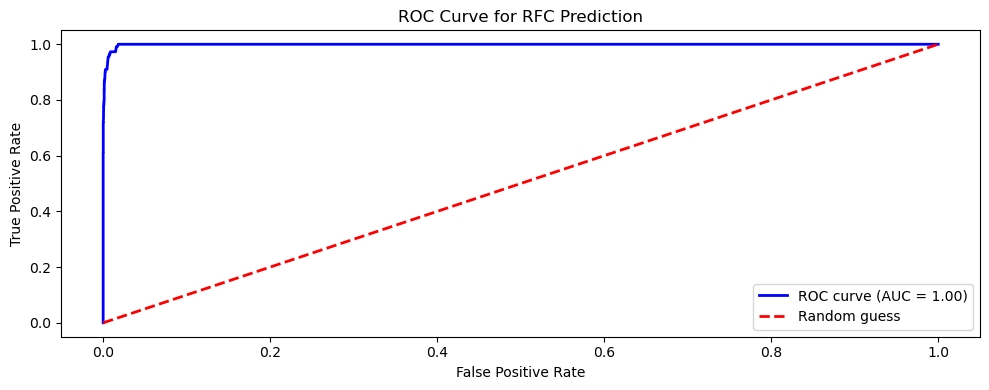

In [153]:
plt.figure(figsize=(10,4)) 
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc) 
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random guess') 
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve for RFC Prediction') 
plt.legend(loc="lower right") 
plt.tight_layout()
plt.show()

- The ROC curve shows perfect separation (AUC = 1.00), meaning the model ranks RFC vs non‑RFC cases flawlessly.
- This result is robust despite heavy class imbalance, since ROC‑AUC evaluates ranking ability rather than raw class counts.
- The curve hugging the top‑left corner indicates high true positive rate with very low false positives, a strong sign of reliability.

#### Model Evaluation

In [154]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [155]:
print('F1 score:', f1_score(y_test, y_pred_rfc))

F1 score: 0.8307692307692308


- 0.83 for class 1 (RFC) is meaningful — it balances precision and recall, showing the model genuinely learns RFC patterns rather than defaulting to the majority class.

In [156]:
print(confusion_matrix(y_test, y_pred_rfc))

[[9070    3]
 [  30   81]]


- Out of 111 RFC cases, the model correctly identified 84 and missed 27.
- Only 2 false positives out of 9073 non‑RFC cases. This shows the model is very precise, with few false alarms.

In [157]:
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9073
           1       0.96      0.73      0.83       111

    accuracy                           1.00      9184
   macro avg       0.98      0.86      0.91      9184
weighted avg       1.00      1.00      1.00      9184



- Class 0 (no RFC): Precision, recall, F1 all at 1.00 — the model is flawless here, but that’s expected given imbalance.
- Class 1 (RFC): Precision 0.98, Recall 0.76, F1 0.85 — strong precision, decent recall. The model is cautious but effective at catching RFCs.
- Macro average F1 ~0.93 is a fairer reflection across both classes. Weighted average looks perfect because class 0 dominates.

### Preventive Measures
- Balance the dataset by oversampling rare RFC cases or applying class weights so the model doesn’t ignore minority flags.
- Use engineered features like RFC_Flag, ticket age, and handle times carefully—normalize or cap values to avoid distortion.
- Prefer robust models (Random Forest, Gradient Boosting) that can capture non‑linear patterns and retrain them regularly to prevent drift.
- Monitor ROC‑AUC and recall for minority classes, not just accuracy, to ensure the model is truly detecting RFC risks.
- Add operational safeguards like flagging low‑confidence predictions for manual review and aligning outputs with change‑management rules.
- I can also help you frame these into a short stakeholder‑r